# GW Spectrum -- Direct Numerical Integration

**Branch:** `decaying-selfsimilar`   **Baseline:** `decaying_turbulence_gw_spectrum_analytic.ipynb`.

Skip the modeling of a two-time decorrelation kernel. Assume

$$F_{ij}(\mathbf{k},t) = \frac{E(k,t)}{4\pi k^2}\bigl(\delta_{ij} - \hat k_i\hat k_j\bigr),$$

take the numerical time Fourier transform $\tilde F_{ij}(\mathbf{k},\omega)$, and feed it into the stationary-case kernel structure (Gaussian / quasi-normal closure). The entire $\omega$-dependence then comes from the decay of $E(k,t)$.

In the aeroacoustic limit $k_{\rm GW}\to 0$, the geometric contraction gives $14/3$, the angular integral gives $4\pi\int dk_1\,k_1^2$, and

$$H_{ijij}(0,\omega) = \frac{14}{3}\cdot\frac{4\pi}{(2\pi)^8}\int dk_1\,k_1^2 \int d\omega_1\;
\tilde\Phi(k_1,\omega_1)\,\tilde\Phi(k_1,\omega-\omega_1),
\qquad \tilde\Phi(k,\omega) = \int_0^\infty dt\,e^{i\omega t}\,\frac{E(k,t)}{4\pi k^2}.$$

Convolution theorem collapses the $\omega_1$ integral:

$$\int d\omega_1\,\tilde\Phi(k,\omega_1)\,\tilde\Phi(k,\omega-\omega_1)
= 2\pi\,\mathcal{F}_t\!\bigl[\Phi(k,t)^2\bigr](\omega),
\qquad \Phi(k,t) \equiv \frac{E(k,t)}{4\pi k^2},$$

giving the implementable form

$$\boxed{\,H_{ijij}(0,\omega) = \frac{7}{48\pi^6}\int dk\,k^2\,\mathcal{F}_t\!\bigl[\Phi(k,t)^2\bigr](\omega).\,}$$

One time-FFT per $k$, one $k$-quadrature. No decorrelation model.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'Notebooks' else Path.cwd()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt
#print(plt.rcParams.keys())
STYLE = {
    "font.size":15
}
plt.rcParams.update(STYLE)


## 1. Scaling laws and single-time spectrum

Shifted-time self-similar form:

$$u^2(t) = u_0^2\bigl(1+t/\tau_*\bigr)^{-p},\quad
L(t) = L_0\bigl(1+t/\tau_*\bigr)^{q},\quad
E(k,t) = u^2(t)\,L(t)\,\phi(kL(t)).$$

Loitsiansky: $p=10/7,\;q=2/7$. Shape $\phi$ piecewise:

$$\phi(\kappa) = \begin{cases}\kappa^{s} & \kappa < 1\\ \kappa^{-5/3} & 1 \le \kappa \le \kappa_d\\ 0 & \kappa > \kappa_d\end{cases}$$

$\tau_*$ is a property of the turbulence decay law and is **held fixed** (we use $\tau_*=L_0=1$). Mach number $M = u_0/c_s$ sets only the amplitude: $u_0 = M$ in units $c_s=1$. What varies between runs is the **duration** $t_{\max}$ over which turbulence has been decaying when we evaluate the GW integral.


### TODO 

 1. Hijkl (k,omega) = function of k for differnt k
 2. Check double fourier trasform gives identity 
 3. Short duration hit for GW vs satationalry GW does decay limits revocvert this cases 

In [2]:
def u_t(t, **pars):
    return pars["u0"] * (1 + t/pars["tau_st"])**(-pars["p"]/2)

def L_t(t, **pars):
    return pars["l0"] * (1 + t/pars["tau_st"])**(pars["q"]/2)

def phi(kappa, s=4, kappa_d=1e3):
    k = np.asarray(kappa, dtype=float)
    out = np.zeros_like(k)
    ir = k < 1.0
    inertial = (k >= 1.0) & (k <= kappa_d)
    out[ir] = k[ir]**s
    out[inertial] = k[inertial]**(-5/3)
    return out

def E_kt(k, t, **pars):
    L = L_t(t, **pars)
    return u_t(t, **pars)**2 * L * phi(k*L, s=pars.get("s", 4), kappa_d=pars.get("kappa_d", 1e3))

def Phi_kt(k, t, **pars):
    return E_kt(k, t, **pars) / (4*np.pi*k**2)


## 2. Time Fourier transform of $F_{ij}$

Causal, one-sided: $\tilde\Phi(k,\omega) = \int_0^{t_{\max}} dt\,e^{i\omega t}\Phi(k,t)$. Evaluated per-$(k,\omega)$ by quadrature for spot checks.


In [3]:
def Phi_tilde(k, omega, t_max=50.0, n_t=4001, **pars):
    ts = np.linspace(0, t_max, n_t)
    vals = Phi_kt(k, ts, **pars)
    return np.trapezoid(vals * np.exp(1j*omega*ts), ts)


## 3. Kernel assembly via FFT

The boxed formula above is evaluated with one FFT per $k$: compute $\Phi(k,t)^2$ on a uniform $t$-grid, FFT in $t$, and quadrature in $k$.


In [4]:
def H_DNI(t_max=50.0, n_t=4001, k_min=1e-3, k_max=1e3, n_k=200, **pars):
    ts = np.linspace(0, t_max, n_t)
    dt = ts[1] - ts[0]
    ks = np.geomspace(k_min, k_max, n_k)
    phi2 = np.array([Phi_kt(k, ts, **pars)**2 for k in ks])
    Ft = dt * np.fft.fftshift(np.fft.fft(phi2, axis=1), axes=1)
    omegas = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(n_t, dt))
    H = 7/(48*np.pi**6) * np.trapezoid(ks[:, None]**2 * Ft.real, ks, axis=0)
    return omegas, H


## 4. Numerical result: duration sweep and Mach sweep

Top: $\Phi(k,t)$ over $k\in[10^{-3},10^{4}]$ (wide enough to expose both the $k^s$ rise at very small $k$, the peak at $k_*=1/L(t)$, and the sharp dissipation cutoff at $k_d=\kappa_d/L(t)$ -- both marked as dotted/dashed verticals per time). Amplitude at every fixed $k$ falls monotonically; the peak drifts left and the cutoff drifts left as $L(t)$ grows.

Middle: $H(0,\omega)$ as the GW-integration window $t_{\max}$ grows at fixed $M$ -- note $t_{\max}$ is the window over which GW power is accumulated (not a snapshot time). Tail saturates once the source has effectively decayed.

Bottom: $H(0,\omega)$ vs Mach number at fixed $t_{\max}$. Peak $\omega$ is Mach-independent (set by $\tau_*$); amplitude scales as $M^4$.

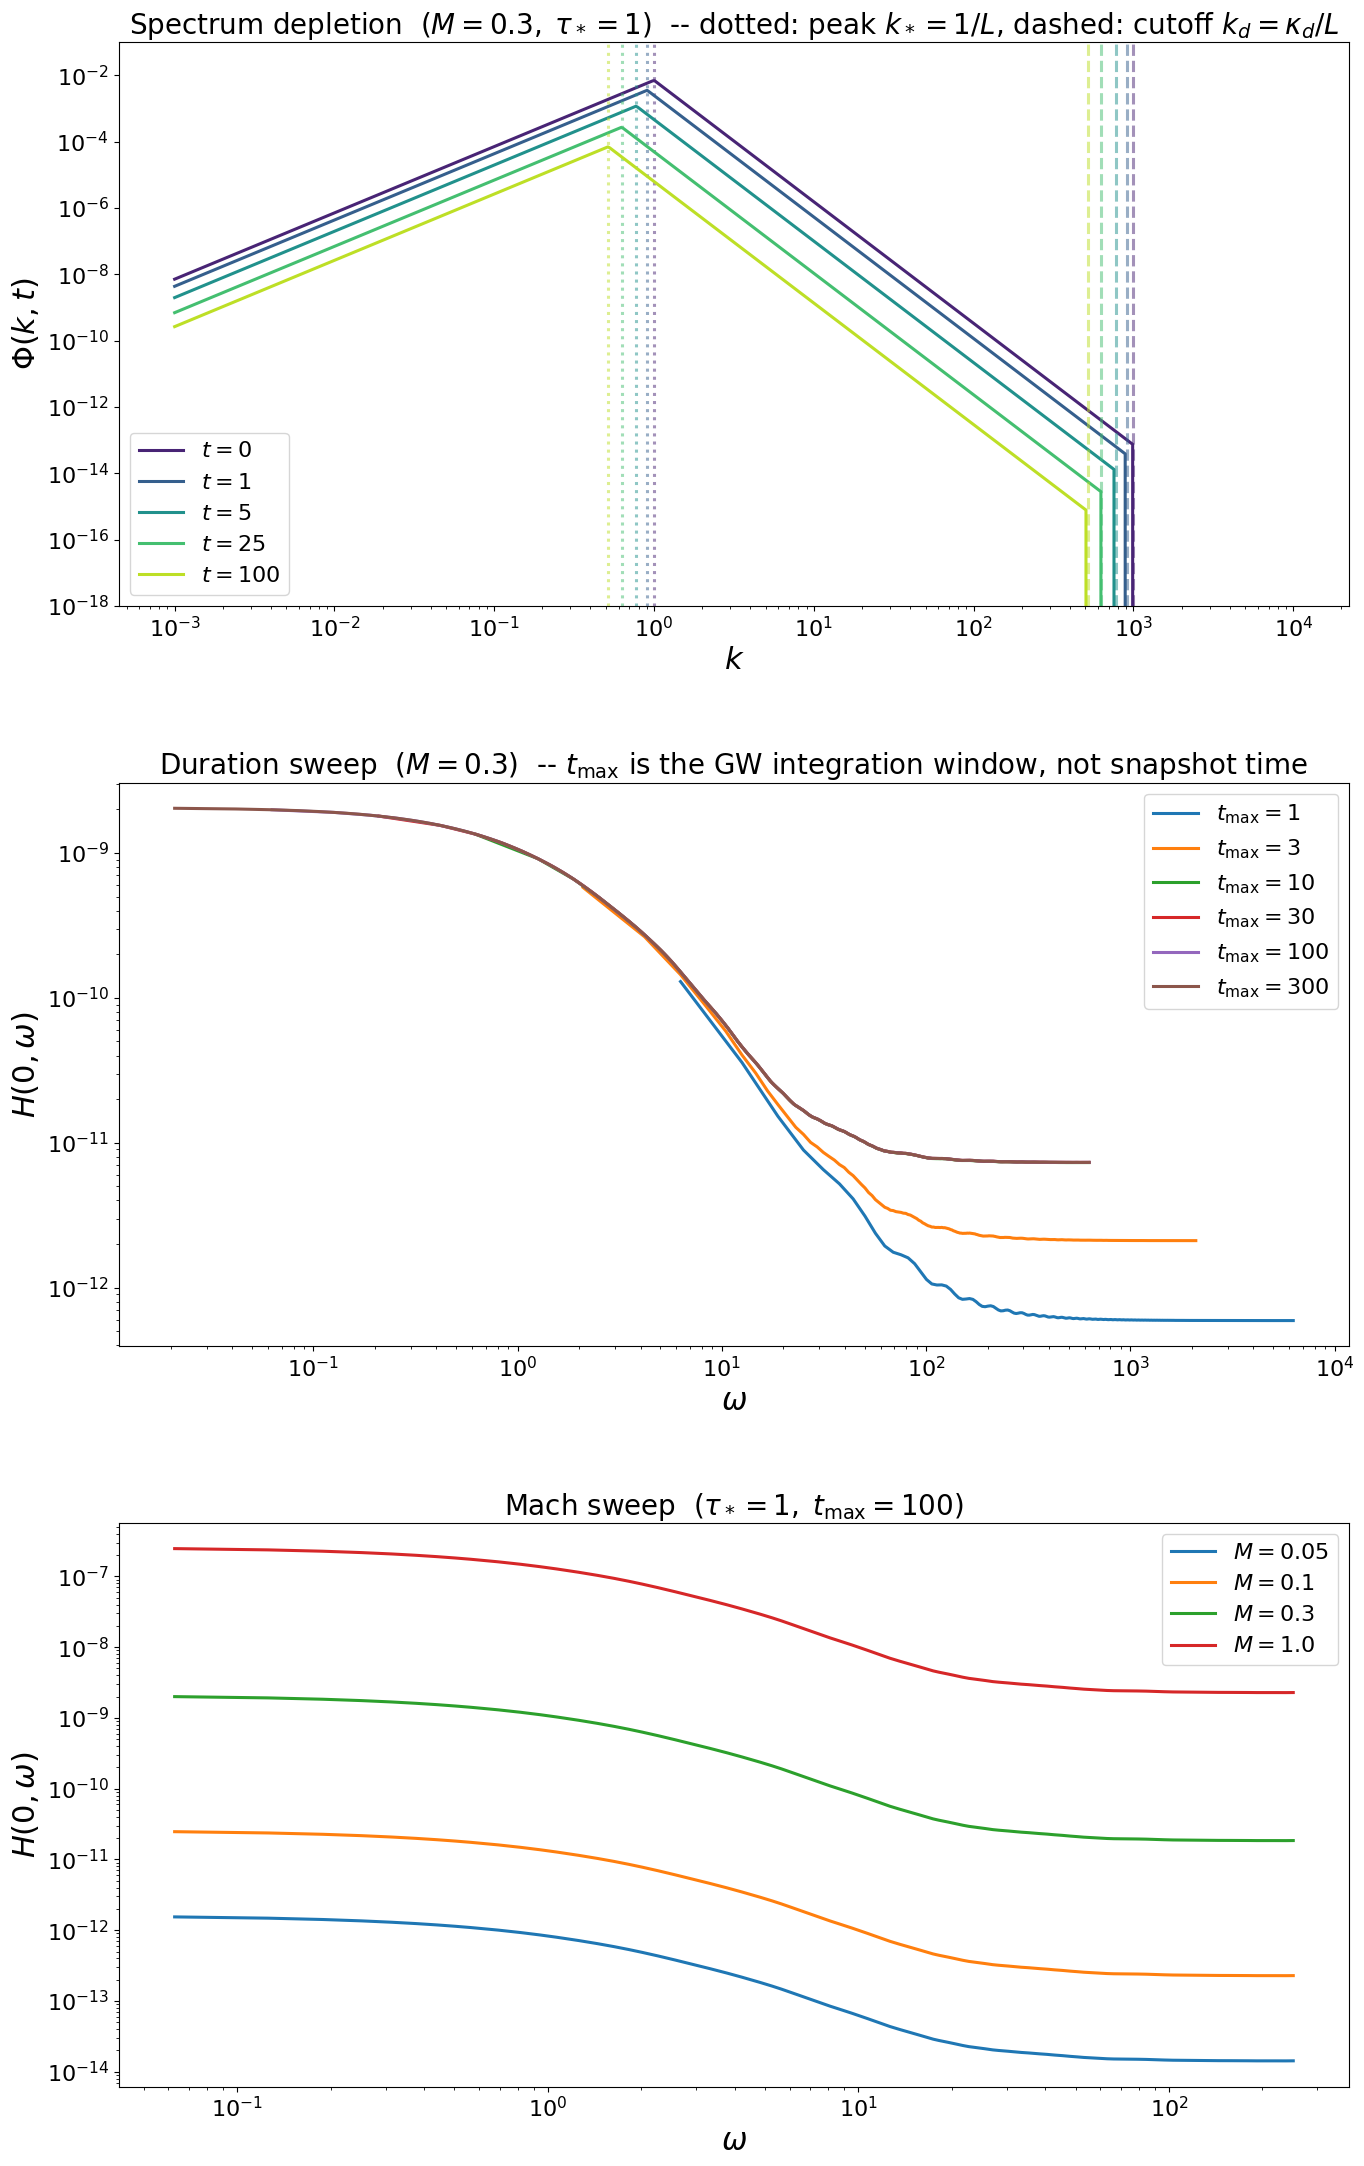

In [5]:
def make_pars(M, tau_st=1.0, T_star=100.0, g_star=100.0, gamma=0.01, zeta=0.01, k0=1.0, **extra):
    return {"u0": M, "l0": 1.0/k0, "tau_st": tau_st, "p": 10/7, "q": 2/7, "s": 4, "kappa_d": 1e3,
            "T_star": T_star, "g_star": g_star, "gamma": gamma, "zeta": zeta, "k0": k0, **extra}

plt.rcParams.update({"font.size": 18, "axes.labelsize": 22, "legend.fontsize": 16,
                     "xtick.labelsize": 16, "ytick.labelsize": 16, "axes.titlesize": 20,
                     "lines.linewidth": 2.2})
Greed = False

fig, ax = plt.subplots(3, 1, figsize=(14, 22))

pars0 = make_pars(0.3)
ks = np.geomspace(1e-3, 1e4, 600)
ts_show = [0.0, 1.0, 5.0, 25.0, 100.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ts_show)))
for t, c in zip(ts_show, colors):
    ax[0].loglog(ks, Phi_kt(ks, t, **pars0), color=c, label=f"$t={t:g}$")
    Lt = L_t(t, **pars0)
    ax[0].axvline(1.0/Lt, color=c, ls=":", alpha=0.5)
    ax[0].axvline(pars0["kappa_d"]/Lt, color=c, ls="--", alpha=0.5)
ax[0].set_xlabel(r"$k$"); ax[0].set_ylabel(r"$\Phi(k,t)$")
ax[0].set_title(r"Spectrum depletion  ($M=0.3,\;\tau_*=1$)  -- dotted: peak $k_*=1/L$, dashed: cutoff $k_d=\kappa_d/L$")
ax[0].set_ylim(1e-18, 1e-1)
ax[0].legend(loc="lower left"); #ax[0].grid(Greed, which="both", alpha=0.3)

for t_max in [1.0, 3.0, 10.0, 30.0, 100.0, 300.0]:
    omegas, H = H_DNI(t_max=t_max, n_t=max(2001, int(200*t_max)+1), k_min=1e-3, k_max=5e3, n_k=160, **pars0)
    m = omegas > 0
    ax[1].loglog(omegas[m], np.abs(H[m]), label=f"$t_{{\\max}}={t_max:g}$")
ax[1].set_xlabel(r"$\omega$"); ax[1].set_ylabel(r"$H(0,\omega)$")
ax[1].set_title(r"Duration sweep  ($M=0.3$)  -- $t_{\max}$ is the GW integration window, not snapshot time")
ax[1].legend(loc="upper right"); #ax[1].grid(Greed, which="both", alpha=0.3)

for M in [0.05, 0.1, 0.3, 1.0]:
    omegas, H = H_DNI(t_max=100.0, n_t=8001, k_min=1e-3, k_max=5e3, n_k=160, **make_pars(M))
    m = omegas > 0
    ax[2].loglog(omegas[m], np.abs(H[m]), label=f"$M={M}$")
ax[2].set_xlabel(r"$\omega$"); ax[2].set_ylabel(r"$H(0,\omega)$")
ax[2].set_title(r"Mach sweep  ($\tau_*=1,\;t_{\max}=100$)")
ax[2].legend(loc="upper right"); #ax[2].grid(Greed, which="both", alpha=0.3)

plt.tight_layout(h_pad=3.0);

## 5. Characteristic strain $h_c(f)$ -- Gogoberidze / Kahniashvili

Observable strain in terms of the GW source kernel (G2007 / K2008):

$$h_c(f) = 1.28\times 10^{-19}\,\Bigl(\frac{100\text{ GeV}}{T_*}\Bigr)\Bigl(\frac{100}{g_*}\Bigr)^{1/3}\Bigl(\frac{\gamma}{0.01}\Bigr)^{3/2}\Bigl(\frac{\zeta}{0.01}\Bigr)^{1/2}\bigl[k_0^3\,\omega_*(f)\,H_{ijij}(\omega_*(f),\omega_*(f))\bigr]^{1/2}.$$

Aeroacoustic approximation $H_{ijij}(\omega_*,\omega_*)\approx H_{ijij}(0,\omega_*)$. Frequency map (turbulence injected at Hubble scale, $\tau_*\sim 1/H_*$):

$$f_0 = \frac{\omega_*}{2\pi}\,f_H^{(0)},\qquad f_H^{(0)} \approx 2.7\times 10^{-5}\text{ Hz}\,\Bigl(\frac{T_*}{100\text{ GeV}}\Bigr)\Bigl(\frac{g_*}{100}\Bigr)^{1/6}.$$

### Normalised axes (G2007 Fig. 1 / K2008 style, $M^{-3/2}$ cancelled)

$$\tilde f \equiv \frac{f}{\text{Hz}}\,\Bigl(\frac{g_*}{100}\Bigr)^{-1/6}\Bigl(\frac{\gamma}{0.01}\Bigr)\Bigl(\frac{T_*}{100\text{ GeV}}\Bigr)^{-1},$$

$$\tilde h_c \equiv h_c(f)\,\Bigl(\frac{g_*}{100}\Bigr)^{1/3}\Bigl(\frac{T_*}{100\text{ GeV}}\Bigr)\Bigl(\frac{\gamma}{0.01}\Bigr)^{-3/2}\Bigl(\frac{\zeta}{0.01}\Bigr)^{-1/2}.$$

Independent experiment parameters: $M,\,\tau_*,\,t_{\max},\,T_*,\,g_*,\,\gamma,\,\zeta,\,k_0$.


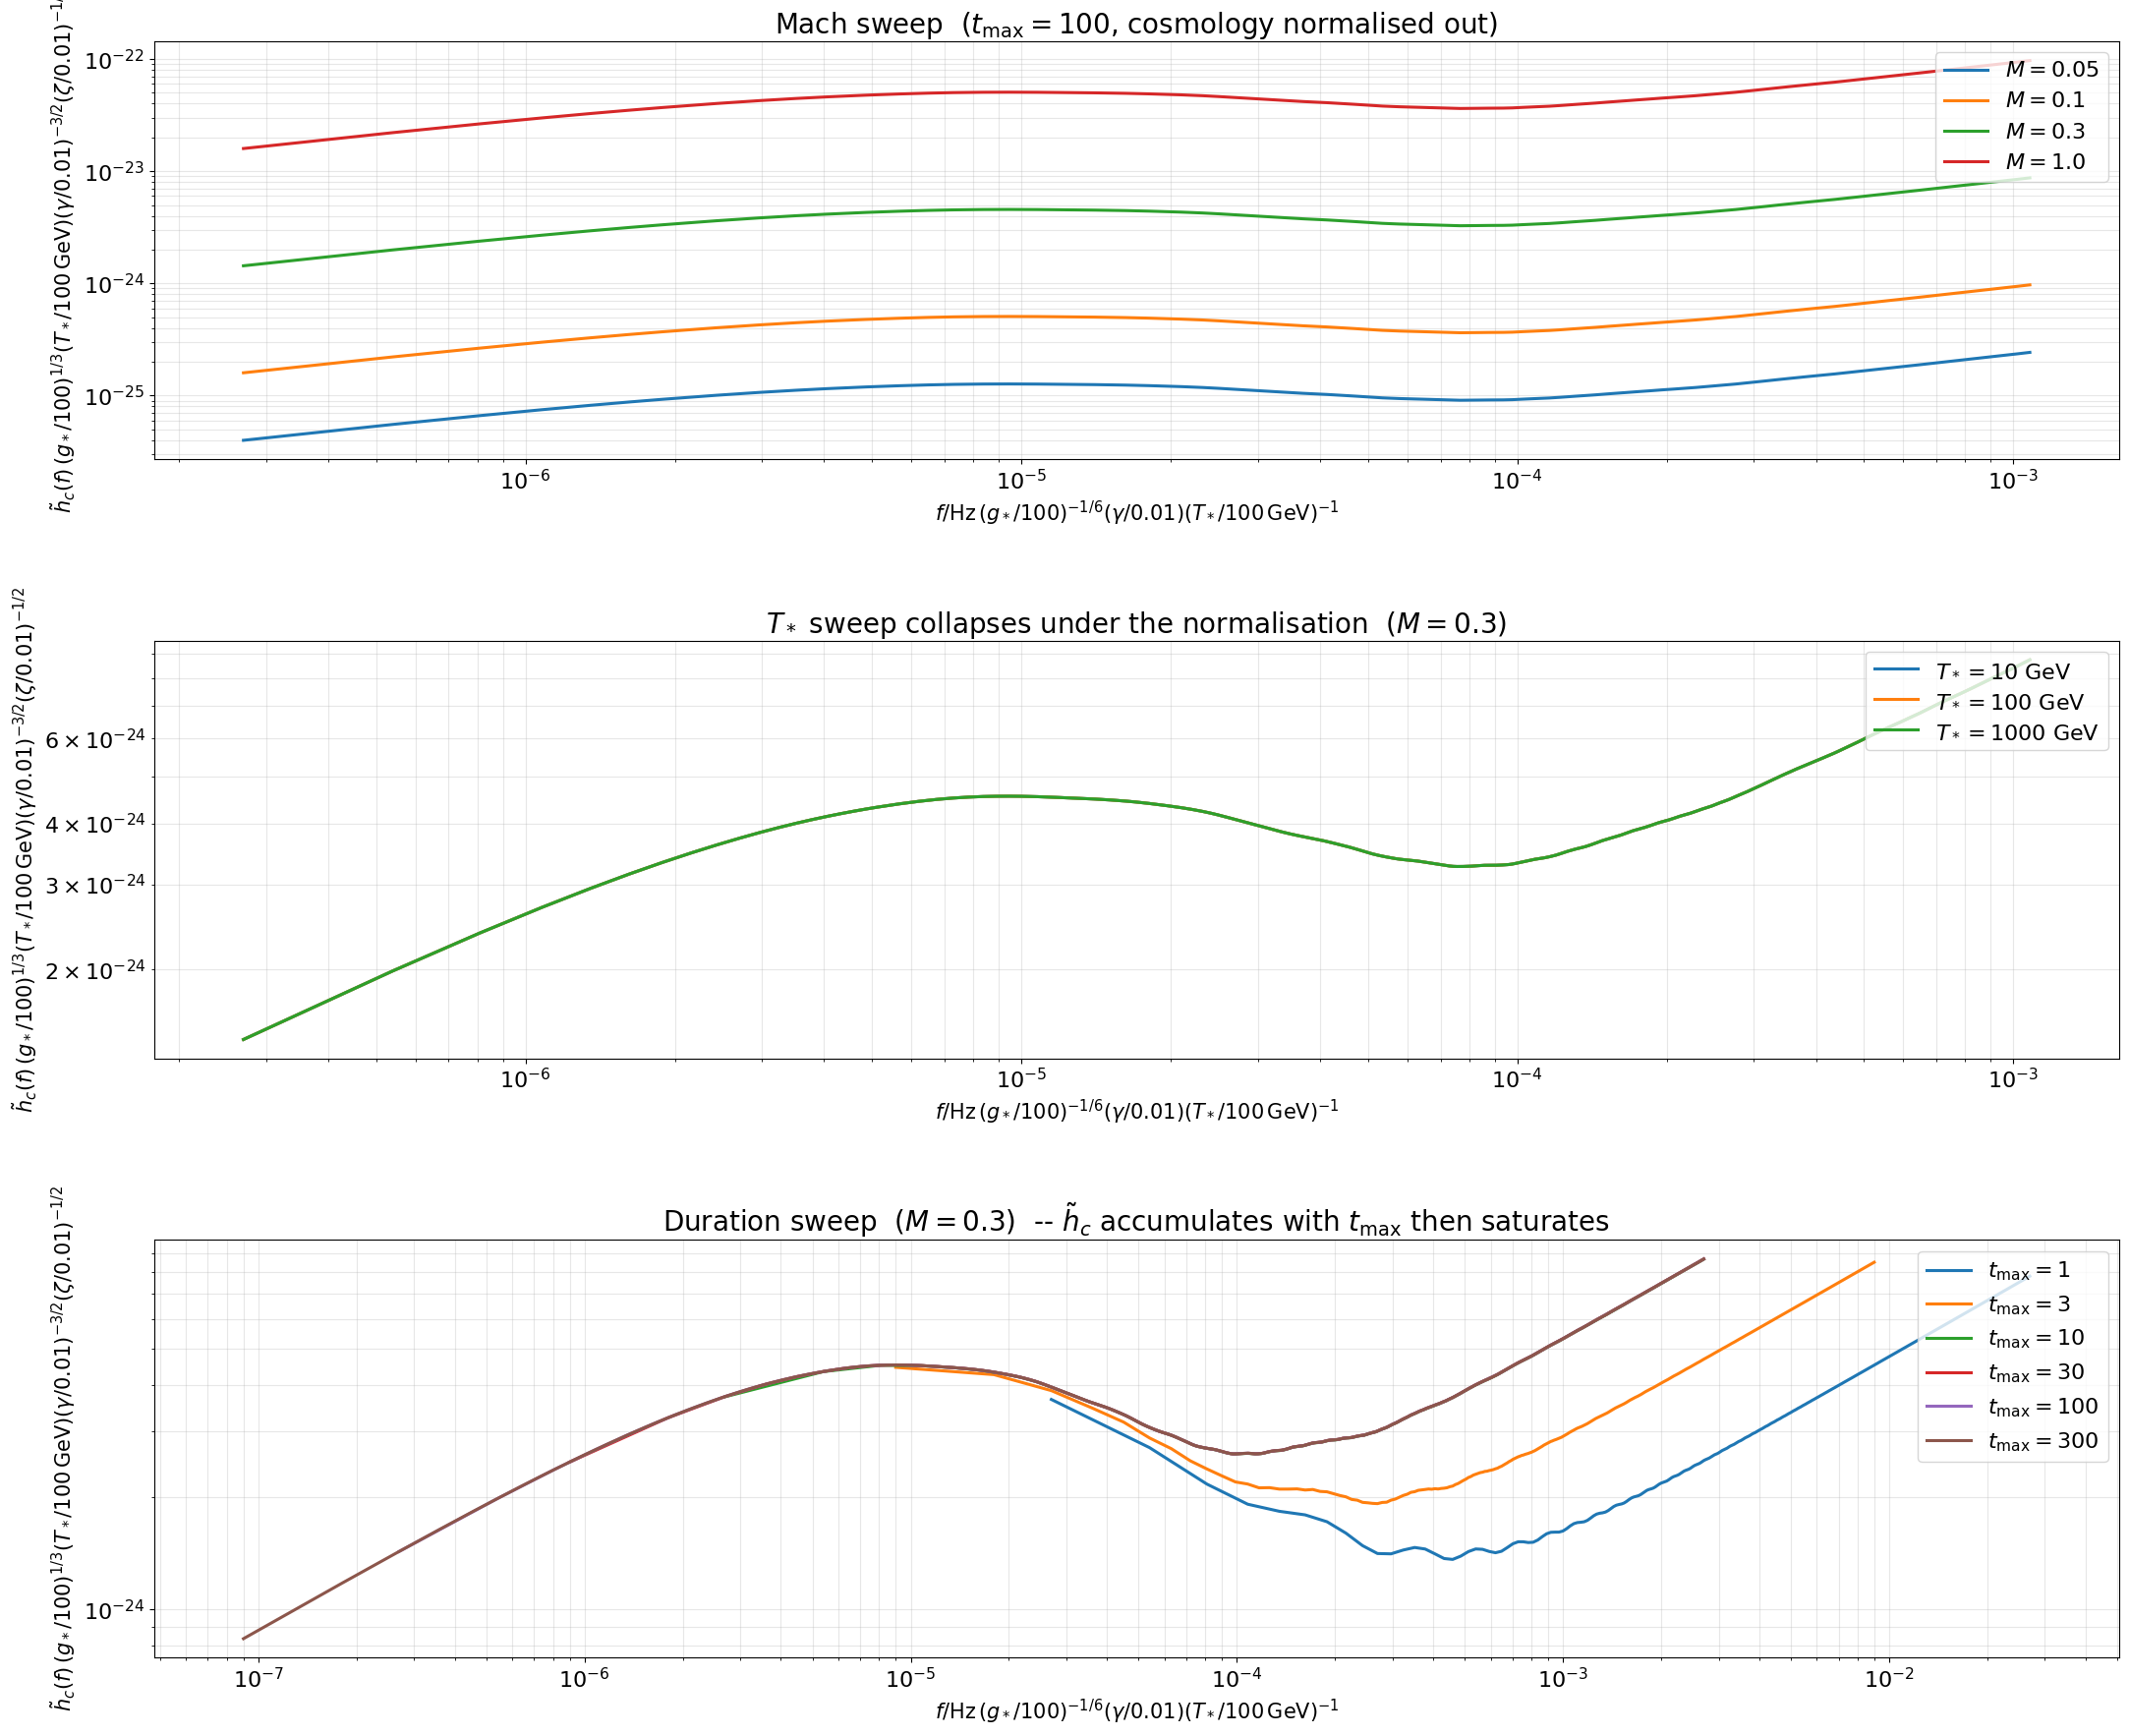

In [6]:
def f_Hz(omega, T_star=100.0, g_star=100.0, **extra):
    return omega/(2*np.pi) * 2.7e-5 * (T_star/100.0) * (g_star/100.0)**(1/6)

def h_c(omega, H, T_star=100.0, g_star=100.0, gamma=0.01, zeta=0.01, k0=1.0, **extra):
    pref = 1.28e-19 * (100.0/T_star) * (100.0/g_star)**(1/3) * (gamma/0.01)**(3/2) * (zeta/0.01)**(1/2)
    return pref * np.sqrt(np.maximum(k0**3 * omega * H, 0.0))

def f_tilde(omega, T_star=100.0, g_star=100.0, gamma=0.01, **extra):
    return f_Hz(omega, T_star=T_star, g_star=g_star) * (g_star/100.0)**(-1/6) * (gamma/0.01) * (T_star/100.0)**(-1)

def h_c_tilde(omega, H, T_star=100.0, g_star=100.0, gamma=0.01, zeta=0.01, k0=1.0, **extra):
    return h_c(omega, H, T_star=T_star, g_star=g_star, gamma=gamma, zeta=zeta, k0=k0) * \
           (g_star/100.0)**(1/3) * (T_star/100.0) * (gamma/0.01)**(-3/2) * (zeta/0.01)**(-1/2)

fig, ax = plt.subplots(3, 1, figsize=(22, 18))

xlbl = r"$f/\mathrm{Hz}\,(g_*/100)^{-1/6}(\gamma/0.01)(T_*/100\,\mathrm{GeV})^{-1}$"
ylbl = r"$\tilde h_c(f)\,(g_*/100)^{1/3}(T_*/100\,\mathrm{GeV})(\gamma/0.01)^{-3/2}(\zeta/0.01)^{-1/2}$"

for M in [0.05, 0.1, 0.3, 1.0]:
    pars = make_pars(M)
    omegas, H = H_DNI(t_max=100.0, n_t=8001, k_min=1e-3, k_max=5e3, n_k=160, **pars)
    m = omegas > 0
    ax[0].loglog(f_tilde(omegas[m], **pars), h_c_tilde(omegas[m], np.abs(H[m]), **pars), label=f"$M={M}$")
ax[0].set_xlabel(xlbl, fontsize=15); ax[0].set_ylabel(ylbl, fontsize=15)
ax[0].set_title(r"Mach sweep  ($t_{\max}=100$, cosmology normalised out)")
ax[0].legend(loc="upper right"); ax[0].grid(True, which="both", alpha=0.3)

for T_star in [10.0, 100.0, 1000.0]:
    pars = make_pars(0.3, T_star=T_star)
    omegas, H = H_DNI(t_max=100.0, n_t=8001, k_min=1e-3, k_max=5e3, n_k=160, **pars)
    m = omegas > 0
    ax[1].loglog(f_tilde(omegas[m], **pars), h_c_tilde(omegas[m], np.abs(H[m]), **pars), label=f"$T_*={T_star:g}$ GeV")
ax[1].set_xlabel(xlbl, fontsize=15); ax[1].set_ylabel(ylbl, fontsize=15)
ax[1].set_title(r"$T_*$ sweep collapses under the normalisation  ($M=0.3$)")
ax[1].legend(loc="upper right"); ax[1].grid(True, which="both", alpha=0.3)

pars = make_pars(0.3)
for t_max in [1.0, 3.0, 10.0, 30.0, 100.0, 300.0]:
    omegas, H = H_DNI(t_max=t_max, n_t=max(2001, int(200*t_max)+1), k_min=1e-3, k_max=5e3, n_k=160, **pars)
    m = omegas > 0
    ax[2].loglog(f_tilde(omegas[m], **pars), h_c_tilde(omegas[m], np.abs(H[m]), **pars), label=f"$t_{{\\max}}={t_max:g}$")
ax[2].set_xlabel(xlbl, fontsize=15); ax[2].set_ylabel(ylbl, fontsize=15)
ax[2].set_title(r"Duration sweep  ($M=0.3$)  -- $\tilde h_c$ accumulates with $t_{\max}$ then saturates")
ax[2].legend(loc="upper right"); ax[2].grid(True, which="both", alpha=0.3)

plt.tight_layout(h_pad=3.0);

## 5b. DNI vs stationary K2008 aeroacoustic -- overlay

Compare DNI $H_{ijij}(0,\omega)$ (envelope-decay only) against the K2008 **stationary** aeroacoustic kernel

$$H^{\rm stat}(0,\omega) = \frac{7 M^3}{16\pi^{3/2}k_0^4}\int_{1/R}^{1}\!dx\,x^{11/4}\,e^{-(\omega/M)^2 x}\,\mathrm{erfc}\bigl(-(\omega/M)\sqrt{x}\bigr),$$

evaluated via `gw_turbulence.core.H_k0_analytic(\omega, M, k0=1, R=\kappa_d)`. Both are in the $k_{\rm GW}\to 0$ aeroacoustic limit; the only difference is the temporal correlator -- Gaussian/Kraichnan eddy decorrelation (stationary) vs. envelope $E(k,t)/(4\pi k^2)$ (DNI). Plotted at the same $M$ and $\kappa_d$. Mismatch expected: stationary decays as $e^{-(\omega/M)^2}$ at high $\omega$, while DNI has a flat/power-law tail from the $t=0$ discontinuity plus missing eddy decorrelation.

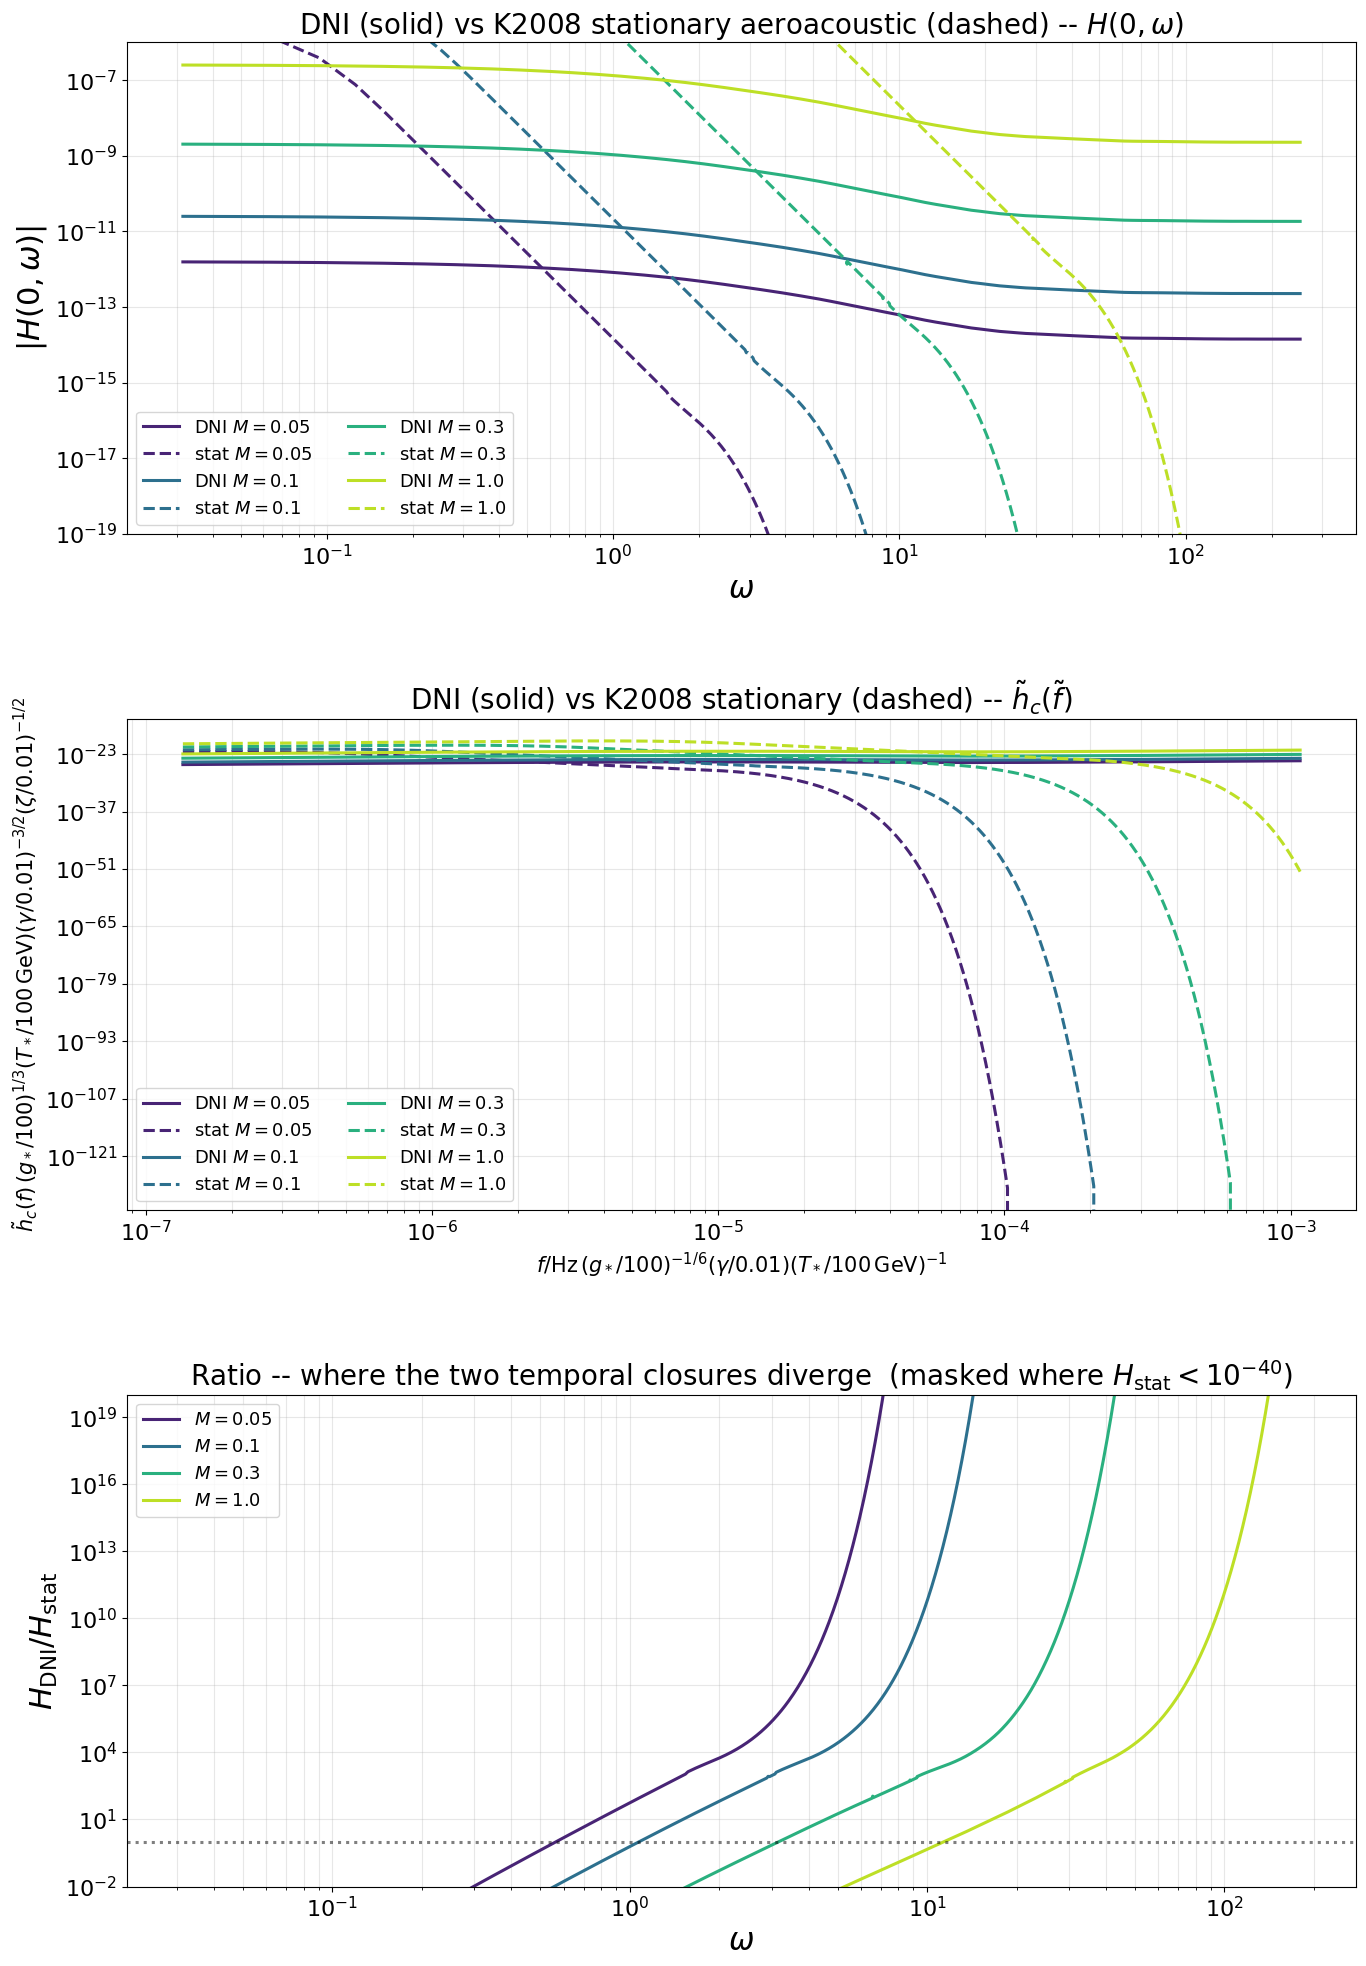

In [7]:
from gw_turbulence.core import H_k0_analytic

fig, ax = plt.subplots(3, 1, figsize=(14, 20))

M_list = [0.05, 0.1, 0.3, 1.0]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(M_list)))

curves = {}
for M, c in zip(M_list, colors):
    pars = make_pars(M)
    omegas, H_dni = H_DNI(t_max=200.0, n_t=16001, k_min=1e-3, k_max=5e3, n_k=160, **pars)
    m = omegas > 0
    om_pos = omegas[m]
    H_dni_pos = np.abs(H_dni[m])
    H_stat = np.abs(H_k0_analytic(om_pos, M=M, k0=pars["k0"], R=pars["kappa_d"]))
    curves[M] = (pars, om_pos, H_dni_pos, H_stat)
    ax[0].loglog(om_pos, H_dni_pos, color=c, lw=2.2, label=f"DNI $M={M}$")
    ax[0].loglog(om_pos, H_stat,    color=c, lw=2.2, ls="--", label=f"stat $M={M}$")
ax[0].set_xlabel(r"$\omega$"); ax[0].set_ylabel(r"$|H(0,\omega)|$")
ax[0].set_title(r"DNI (solid) vs K2008 stationary aeroacoustic (dashed) -- $H(0,\omega)$")
ax[0].legend(loc="lower left", ncol=2, fontsize=13); ax[0].grid(True, which="both", alpha=0.3)
ax[0].set_ylim(1e-19, 1e-6)

for M, c in zip(M_list, colors):
    pars, om_pos, H_dni_pos, H_stat = curves[M]
    ax[1].loglog(f_tilde(om_pos, **pars), h_c_tilde(om_pos, H_dni_pos, **pars),
                 color=c, lw=2.2, label=f"DNI $M={M}$")
    ax[1].loglog(f_tilde(om_pos, **pars), h_c_tilde(om_pos, H_stat, **pars),
                 color=c, lw=2.2, ls="--", label=f"stat $M={M}$")
ax[1].set_xlabel(xlbl, fontsize=15); ax[1].set_ylabel(ylbl, fontsize=15)
ax[1].set_title(r"DNI (solid) vs K2008 stationary (dashed) -- $\tilde h_c(\tilde f)$")
ax[1].legend(loc="lower left", ncol=2, fontsize=13); ax[1].grid(True, which="both", alpha=0.3)

H_STAT_FLOOR = 1e-40
for M, c in zip(M_list, colors):
    _, om_pos, H_dni_pos, H_stat = curves[M]
    valid = (H_stat > H_STAT_FLOOR) & (H_dni_pos > 0)
    ratio = np.full_like(om_pos, np.nan, dtype=float)
    ratio[valid] = H_dni_pos[valid] / H_stat[valid]
    ax[2].loglog(om_pos, ratio, color=c, lw=2.2, label=f"$M={M}$")
ax[2].axhline(1.0, color="k", ls=":", alpha=0.5)
ax[2].set_xlabel(r"$\omega$"); ax[2].set_ylabel(r"$H_{\rm DNI}/H_{\rm stat}$")
ax[2].set_title(r"Ratio -- where the two temporal closures diverge  (masked where $H_{\rm stat}<10^{-40}$)")
ax[2].set_ylim(1e-2, 1e20)
ax[2].legend(loc="upper left", fontsize=13); ax[2].grid(True, which="both", alpha=0.3)

plt.tight_layout(h_pad=3.0);

## 6. TODO items -- direct checks

### 6.1 Finite $k_{GW}$ kernel  (TODO #1)

Drop the aeroacoustic $k_{GW}\to 0$ approximation. With $F_{ij}(\vec q,t)=\Phi(q,t)P_{ij}(\hat q)$ and Wick contraction of two velocity fields, the $\Lambda$-projected source reads

$$H(k_{GW},\omega) = \frac{7}{48\pi^6}\cdot\frac{15}{76}\int_{q_{\min}}^{q_{\max}}\! dq\,q^2 \int_{-1}^{1}\!d\gamma\,\mathcal{K}(\gamma;k_{GW},q)\,\mathcal{F}_t\!\bigl[\Phi(q,t)\Phi(\tilde q,t)\bigr](\omega),$$

with $\tilde q = \sqrt{k_{GW}^2 + q^2 - 2 k_{GW} q \gamma}$, $\beta=(k_{GW}-q\gamma)/\tilde q$, $c=(k_{GW}\gamma-q)/\tilde q$, and

$$\mathcal{K}(\gamma;k_{GW},q) \;=\; 2 + \gamma^2 + \beta^2 + \gamma^2\beta^2 - c^2 + 2\gamma\beta c.$$

At $k_{GW}\to 0$: $\beta=-\gamma,\,c=-1,\,\tilde q=q,\,\mathcal{K}=1+4\gamma^2+\gamma^4$, and $\int_{-1}^{1}\mathcal{K}\,d\gamma = 76/15$, so the formula collapses to the Sec.3 aeroacoustic expression. The explicit $(15/76)$ prefactor is chosen so $k_{GW}=0$ lines up with `H_DNI`. **Expectation:** for $k_{GW}\ll k_*$ the shape is $k_{GW}$-independent (aeroacoustic regime); for $k_{GW}\gtrsim k_*$ the triad constraint drops the amplitude and cuts the low-$\omega$ plateau.

### 6.2 Double-FT / convolution identity  (TODO #2)

The Sec.3 reduction uses

$$\int d\omega_1\;\tilde\Phi(k,\omega_1)\,\tilde\Phi(k,\omega-\omega_1) \;=\; 2\pi\,\mathcal{F}_t\!\bigl[\Phi(k,t)^2\bigr](\omega).$$

Evaluate both sides independently at a fixed $k$ (direct FFT of $\Phi^2$ vs. discrete $\omega$-convolution of $\tilde\Phi$ with itself) and also report the IFFT round-trip and Parseval equality. Agreement to numerical precision (with truncation error dominating near the edges of the \omega-grid) confirms the derivation step.

### 6.3 Duration limits vs stationary  (TODO #3)

Sweep $t_{\max}$ from short burst to long decay and overlay the K2008 stationary aeroacoustic kernel at the same $M$.

- Short burst ($t_{\max}\ll\tau_*$): $\Phi(k,t)\approx\Phi(k,0)$; rectangle-windowed constant \to  sinc-like spectrum concentrated near $\omega=0$ with width $\sim 1/t_{\max}$.
- Long decay ($t_{\max}\gg\tau_*$): the transient contribution saturates.
- Stationary K2008: continuous forcing with eddy decorrelation \to  Gaussian cutoff $\sim e^{-(\omega/M)^2}$.

Neither DNI limit recovers the stationary tail, because DNI models only the envelope decay, not the fast eddy turnover that drives the K2008 cutoff.

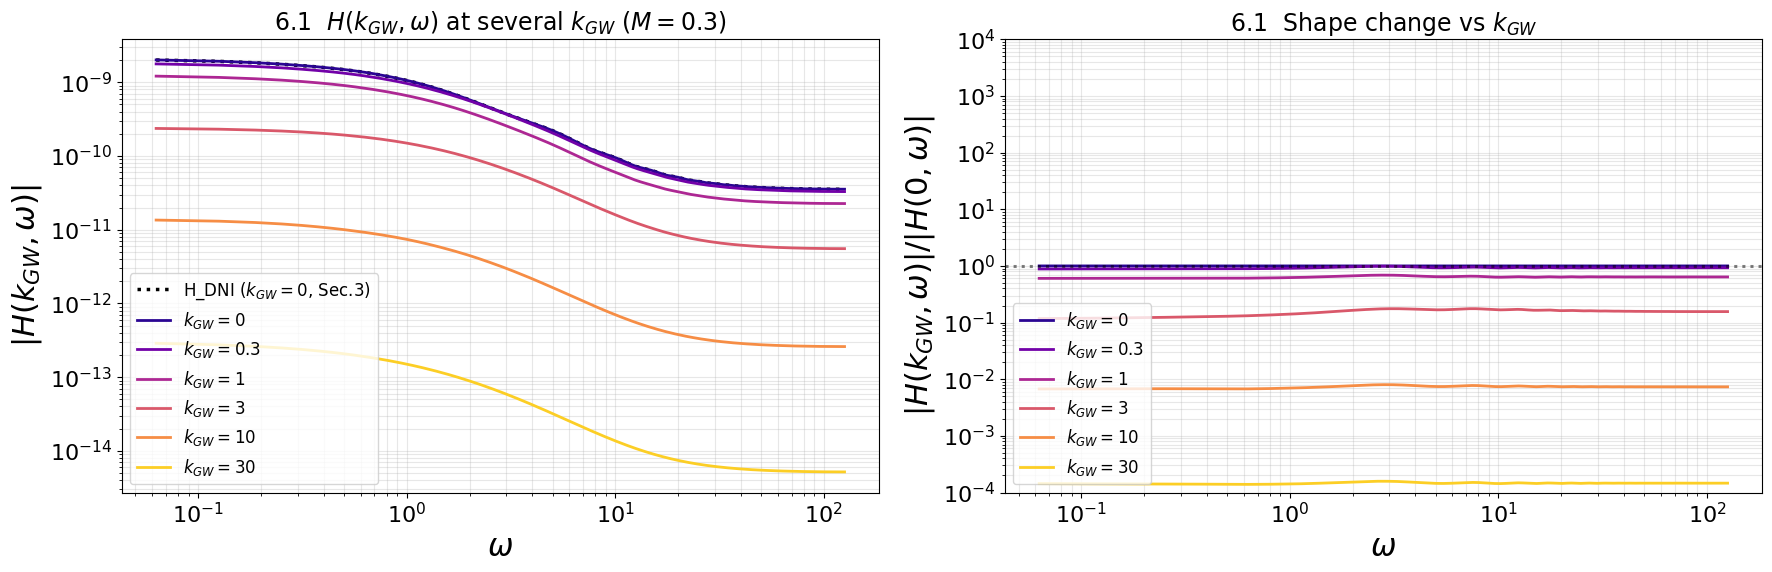

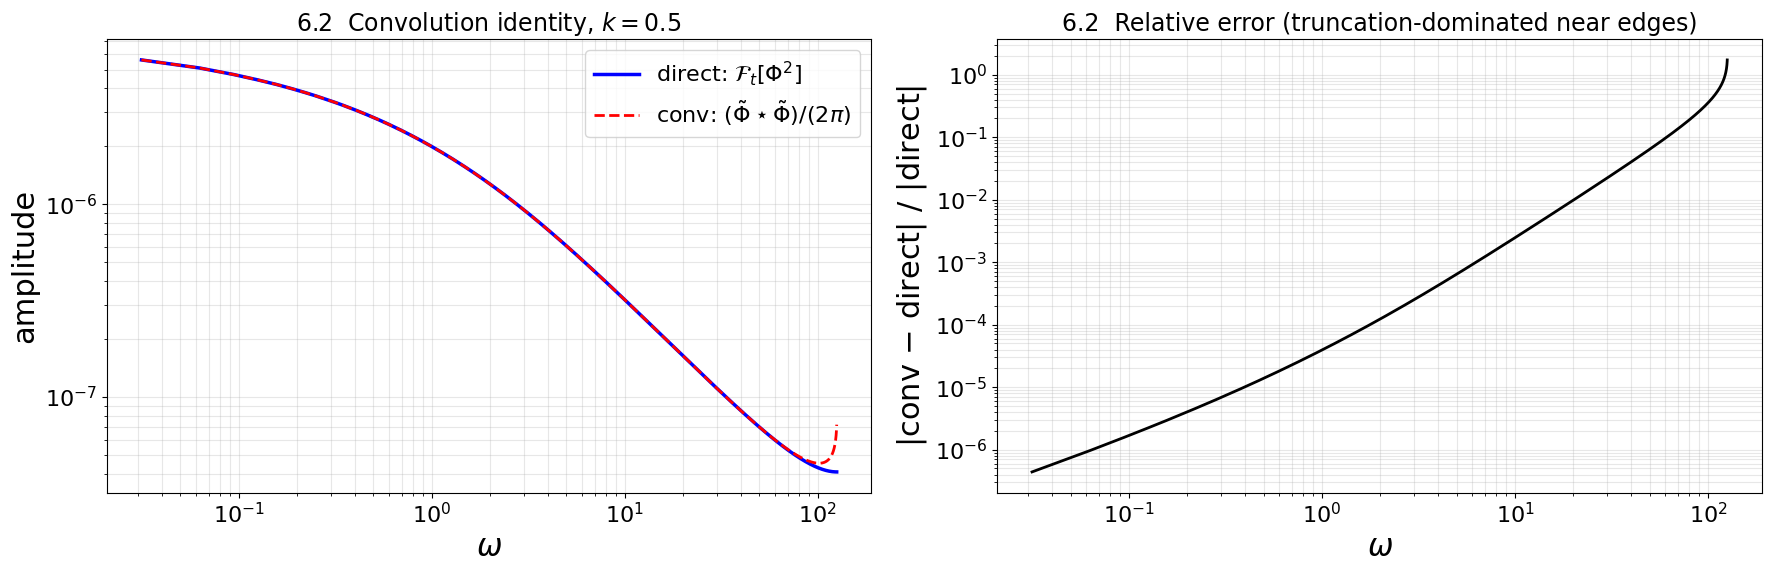

[6.2] IFFT roundtrip max err = 8.674e-19
[6.2] Parseval \int |\Phi|^2 dt       = 6.703659e-06
[6.2] Parseval \int |\tilde{\Phi}|^2 d\omega/2\pi    = 6.703659e-06
[6.2] relative difference      = 2.523e-13


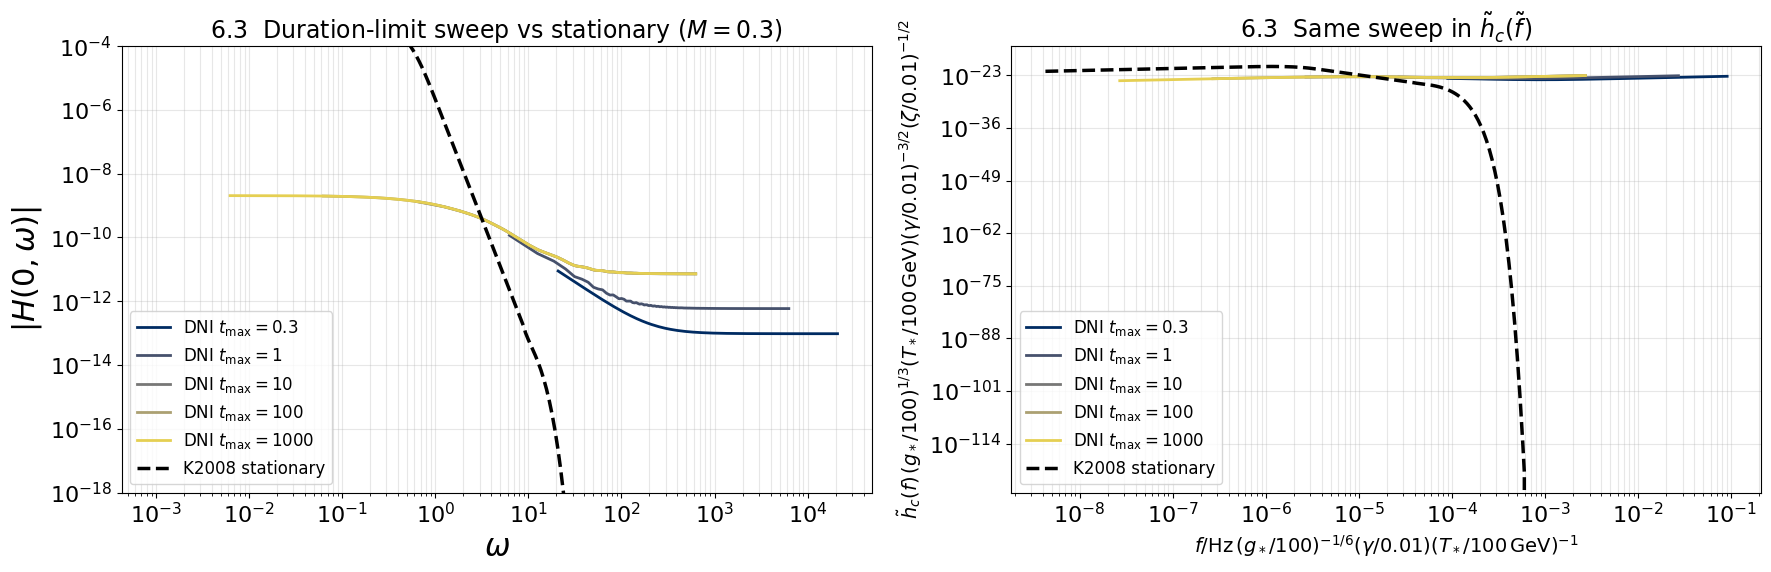

In [8]:
# =============================================================================
# 6.1  Finite k_GW kernel  (TODO #1)
# =============================================================================
def H_DNI_kgw(k_gw, t_max=100.0, n_t=4001, q_min=1e-3, q_max=1e3,
              n_q=60, n_gamma=24, **pars):
    ts = np.linspace(0, t_max, n_t); dt = ts[1] - ts[0]
    qs = np.geomspace(q_min, q_max, n_q)
    gammas = np.linspace(-1.0, 1.0, n_gamma)
    omegas = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(n_t, dt))
    integrand = np.zeros((n_q, n_gamma, n_t))
    for iq, q in enumerate(qs):
        Phi_q = Phi_kt(q, ts, **pars)
        for ig, g in enumerate(gammas):
            p = np.sqrt(max(k_gw**2 + q**2 - 2*k_gw*q*g, 0.0))
            if p < 1e-30:
                continue
            Phi_p = Phi_kt(p, ts, **pars)
            if k_gw > 0:
                beta = (k_gw - q*g) / p
                c_qp = (k_gw*g - q) / p
            else:
                beta = -g; c_qp = -1.0
            K = 2 + g**2 + beta**2 + (g*beta)**2 - c_qp**2 + 2*g*beta*c_qp
            Ft = dt * np.fft.fftshift(np.fft.fft(Phi_q * Phi_p))
            integrand[iq, ig, :] = q**2 * K * Ft.real
    H_w = np.trapezoid(np.trapezoid(integrand, gammas, axis=1), qs, axis=0)
    return omegas, (7.0/(48*np.pi**6)) * (15.0/76.0) * H_w

plt.rcParams.update({"font.size": 16, "axes.titlesize": 17})
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
pars_61 = make_pars(0.3)
k_gw_list = [0.0, 0.3, 1.0, 3.0, 10.0, 30.0]
colors_61 = plt.cm.plasma(np.linspace(0.05, 0.9, len(k_gw_list)))
kgw_curves = {}
for k_gw in k_gw_list:
    om, H = H_DNI_kgw(k_gw, t_max=100.0, n_t=4001, n_q=60, n_gamma=24, **pars_61)
    m = om > 0
    kgw_curves[k_gw] = (om[m], np.abs(H[m]))

om_ref, H_ref = H_DNI(t_max=100.0, n_t=4001, k_min=1e-3, k_max=1e3, n_k=60, **pars_61)
m_ref = om_ref > 0
ax[0].loglog(om_ref[m_ref], np.abs(H_ref[m_ref]), "k:", lw=2.5, label=r"H_DNI ($k_{GW}=0$, Sec.3)")
for k_gw, c in zip(k_gw_list, colors_61):
    om_pos, H_pos = kgw_curves[k_gw]
    ax[0].loglog(om_pos, H_pos, color=c, lw=2, label=f"$k_{{GW}}={k_gw:g}$")
ax[0].set_xlabel(r"$\omega$"); ax[0].set_ylabel(r"$|H(k_{GW},\omega)|$")
ax[0].set_title(r"6.1  $H(k_{GW},\omega)$ at several $k_{GW}$ ($M=0.3$)")
ax[0].legend(loc="lower left", fontsize=12); ax[0].grid(True, which="both", alpha=0.3)

om0_pos, H0_pos = kgw_curves[0.0]
for k_gw, c in zip(k_gw_list, colors_61):
    om_pos, H_pos = kgw_curves[k_gw]
    valid = (H0_pos > 1e-40) & (H_pos > 0)
    ratio = np.full_like(om_pos, np.nan, dtype=float)
    ratio[valid] = H_pos[valid] / H0_pos[valid]
    ax[1].loglog(om_pos, ratio, color=c, lw=2, label=f"$k_{{GW}}={k_gw:g}$")
ax[1].axhline(1.0, color="k", ls=":", alpha=0.5)
ax[1].set_xlabel(r"$\omega$"); ax[1].set_ylabel(r"$|H(k_{GW},\omega)|/|H(0,\omega)|$")
ax[1].set_title(r"6.1  Shape change vs $k_{GW}$")
ax[1].set_ylim(1e-4, 1e4)
ax[1].legend(loc="lower left", fontsize=12); ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

# =============================================================================
# 6.2  Double-FT / convolution identity  (TODO #2)
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
k_test = 0.5
t_max_62 = 200.0
n_t_62 = 8001
ts_62 = np.linspace(0, t_max_62, n_t_62)
dt_62 = ts_62[1] - ts_62[0]
pars_62 = make_pars(0.3)
phi_t_62 = Phi_kt(k_test, ts_62, **pars_62)
F_phi2 = dt_62 * np.fft.fftshift(np.fft.fft(phi_t_62**2))
F_phi  = dt_62 * np.fft.fftshift(np.fft.fft(phi_t_62))
omegas_62 = 2*np.pi * np.fft.fftshift(np.fft.fftfreq(n_t_62, dt_62))
d_omega_62 = omegas_62[1] - omegas_62[0]
conv_FF = d_omega_62 * np.convolve(F_phi, F_phi, mode="same") / (2*np.pi)
m62 = omegas_62 > 0

ax[0].loglog(omegas_62[m62], np.abs(F_phi2[m62]), "b-",  lw=2.5, label=r"direct: $\mathcal{F}_t[\Phi^2]$")
ax[0].loglog(omegas_62[m62], np.abs(conv_FF[m62]), "r--", lw=2,   label=r"conv: $(\tilde\Phi\star\tilde\Phi)/(2\pi)$")
ax[0].set_xlabel(r"$\omega$"); ax[0].set_ylabel("amplitude")
ax[0].set_title(fr"6.2  Convolution identity, $k={k_test}$")
ax[0].legend(loc="upper right"); ax[0].grid(True, which="both", alpha=0.3)

rel_err = np.abs(conv_FF - F_phi2) / np.maximum(np.abs(F_phi2), 1e-30)
ax[1].loglog(omegas_62[m62], rel_err[m62], "k-", lw=2)
ax[1].set_xlabel(r"$\omega$"); ax[1].set_ylabel("|conv $-$ direct| / |direct|")
ax[1].set_title("6.2  Relative error (truncation-dominated near edges)")
ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

phi_back = np.real(np.fft.ifft(np.fft.ifftshift(F_phi) / dt_62))
roundtrip_err = np.max(np.abs(phi_back - phi_t_62))
parseval_t = np.sum(np.abs(phi_t_62)**2) * dt_62
parseval_w = np.sum(np.abs(F_phi)**2) * d_omega_62 / (2*np.pi)
print(f"[6.2] IFFT roundtrip max err = {roundtrip_err:.3e}")
print(rf"[6.2] Parseval \int |\Phi|^2 dt       = {parseval_t:.6e}")
print(rf"[6.2] Parseval \int |\tilde{{\Phi}}|^2 d\omega/2\pi    = {parseval_w:.6e}")
print(f"[6.2] relative difference      = {abs(parseval_t - parseval_w)/parseval_t:.3e}")

# =============================================================================
# 6.3  Duration-limit sweep vs stationary  (TODO #3)
# =============================================================================
fig, ax = plt.subplots(1, 2, figsize=(18, 6))
M_63 = 0.3
pars_63 = make_pars(M_63)
tmax_list = [0.3, 1.0, 10.0, 100.0, 1000.0]
colors_63 = plt.cm.cividis(np.linspace(0.05, 0.9, len(tmax_list)))
om_stat_63 = np.geomspace(1e-3, 1e3, 400)
H_stat_63 = np.abs(H_k0_analytic(om_stat_63, M=M_63, k0=pars_63["k0"], R=pars_63["kappa_d"]))

curves_63 = {}
for t_max in tmax_list:
    n_t_ad = max(2001, int(200*t_max)+1)
    om, H = H_DNI(t_max=t_max, n_t=n_t_ad, k_min=1e-3, k_max=5e3, n_k=120, **pars_63)
    m = om > 0
    curves_63[t_max] = (om[m], np.abs(H[m]))

for t_max, c in zip(tmax_list, colors_63):
    om_pos, H_pos = curves_63[t_max]
    ax[0].loglog(om_pos, H_pos, color=c, lw=2, label=fr"DNI $t_{{\max}}={t_max:g}$")
ax[0].loglog(om_stat_63, H_stat_63, "k--", lw=2.5, label="K2008 stationary")
ax[0].set_xlabel(r"$\omega$"); ax[0].set_ylabel(r"$|H(0,\omega)|$")
ax[0].set_title(fr"6.3  Duration-limit sweep vs stationary ($M={M_63}$)")
ax[0].set_ylim(1e-18, 1e-4)
ax[0].legend(loc="lower left", fontsize=12); ax[0].grid(True, which="both", alpha=0.3)

for t_max, c in zip(tmax_list, colors_63):
    om_pos, H_pos = curves_63[t_max]
    ax[1].loglog(f_tilde(om_pos, **pars_63),
                 h_c_tilde(om_pos, H_pos, **pars_63),
                 color=c, lw=2, label=fr"DNI $t_{{\max}}={t_max:g}$")
ax[1].loglog(f_tilde(om_stat_63, **pars_63),
             h_c_tilde(om_stat_63, H_stat_63, **pars_63),
             "k--", lw=2.5, label="K2008 stationary")
ax[1].set_xlabel(xlbl, fontsize=14); ax[1].set_ylabel(ylbl, fontsize=14)
ax[1].set_title(r"6.3  Same sweep in $\tilde h_c(\tilde f)$")
ax[1].legend(loc="lower left", fontsize=12); ax[1].grid(True, which="both", alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Cross-checks to run

- **Frozen limit ($\tau_*\to\infty$):** $E(k,t)\to E(k)$ so $\Phi(k,t)^2\to\Phi(k)^2$ is constant in $t$ and $\mathcal{F}_t[\Phi^2](\omega)\propto\delta(\omega)$. The DNI result collapses to a delta at $\omega=0$ -- the DNI ansatz encodes all temporal power in the $E(k,t)$ decay, so the stationary limit is trivially zero power away from $\omega=0$. This is a feature, not a bug: DNI is not the same model as BK2016 and should not match.
- **High-$\omega$ tail:** set by the short-time behaviour of $\Phi(k,t)^2$ near $t=0^+$. Expected tail $\omega^{-9/7}$ at the peak scale for Loitsiansky.
- **Grid convergence:** double `n_t` and `t_max`; DNI tail should not move.
- **$M^4$ scaling:** $h_c\propto M^2$ at fixed $f$ (since $H\propto M^4$). Verify on the Mach-sweep panel.
- **$T_*$ scaling:** $h_c\propto 1/T_*$ from the overall prefactor; $f\propto T_*$ from the redshift map. Check both.


---

## Scratch


In [9]:
# scratch
